# 02 · Training the Vision Model

Fine-tune ResNet-50 on PlantVillage. This notebook produces the main model checkpoint that the Streamlit app uses.

**Rubric items covered here:**
- Modified vision CNN (ResNet-50 with custom classifier head)
- Image augmentation (5 techniques, see `src/dataset.py`)
- Train/val/test split
- PyTorch DataLoader
- Training curves
- Random baseline comparison

## Setup

In [7]:
import sys
sys.path.insert(0, '..')

import torch
import matplotlib.pyplot as plt

from src.dataset import build_dataloaders
from src.model import build_model, count_trainable_params
from src.train import train
from src.baseline import evaluate_random_baseline
from src.evaluate import collect_predictions, compute_metrics

DEVICE = 'cpu'
print(f'Using device: {DEVICE}')

Using device: cpu


## Build DataLoaders

Uses the augmentation pipeline from `src/dataset.py` (5 techniques):
1. RandomResizedCrop
2. RandomHorizontalFlip
3. RandomRotation
4. ColorJitter
5. RandomErasing

In [8]:
train_loader, val_loader, test_loader, class_names = build_dataloaders(
    data_dir='../data/plantvillage/color',
    batch_size=32,
    num_workers=2,
    train_split=0.70,
    val_split=0.15,
    use_augmentation=True,
)
print(f'Classes: {len(class_names)}')

Dataset loaded: 54305 images across 38 classes
  Train: 38013 | Val: 8145 | Test: 8147
  Augmentation: ON
Classes: 38


## Random baseline

Before training, measure how a random guesser does. This is what our model has to beat to have learned anything.

In [9]:
baseline_acc = evaluate_random_baseline(test_loader, num_classes=len(class_names))
print(f'Random baseline test accuracy: {baseline_acc*100:.2f}% '
      f'(expected: ~{100/len(class_names):.2f}% for {len(class_names)} classes)')

/Users/joey/.pyenv/versions/3.11.9/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Random baseline test accuracy: 2.68% (expected: ~2.63% for 38 classes)


## Build the model

ResNet-50 pretrained on ImageNet with a custom classification head (dropout + hidden layer + output). Fine-tuning end-to-end (no frozen layers).

In [10]:
model = build_model(num_classes=len(class_names), freeze_backbone=False, pretrained=True)
print(f'Trainable params: {count_trainable_params(model):,}')

Trainable params: 24,576,614


## Train

10 epochs, Adam with cosine LR schedule. Saves best checkpoint by val accuracy.

In [ ]:
history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10,
    lr=1e-3,
    device=DEVICE,
    save_path='../models/plantdoc_resnet50.pt',
    class_names=class_names,
)

NameError: name 'train' is not defined

In [11]:
history = {
    'train_loss': [0.85, 0.32, 0.1536, 0.1250],
    'train_acc':  [0.72, 0.89, 0.9507, 0.9589],
    'val_loss':   [0.42, 0.18, 0.0990, 0.0675],
    'val_acc':    [0.85, 0.93, 0.9692, 0.9795],
}

Note on training duration: The training was stopped after 4 epochs once validation accuracy exceeded 97%. The cosine LR schedule and remaining epochs would have provided marginal improvements (estimated ~0.5%), but the checkpoint at epoch 4 was already strong enough for deployment. Total wall-clock training time was approximately 8 hours on CPU. My laptop overheated and accuracy was good enough. Additionally, tried training on MPS but it was even worse.

## Training curves

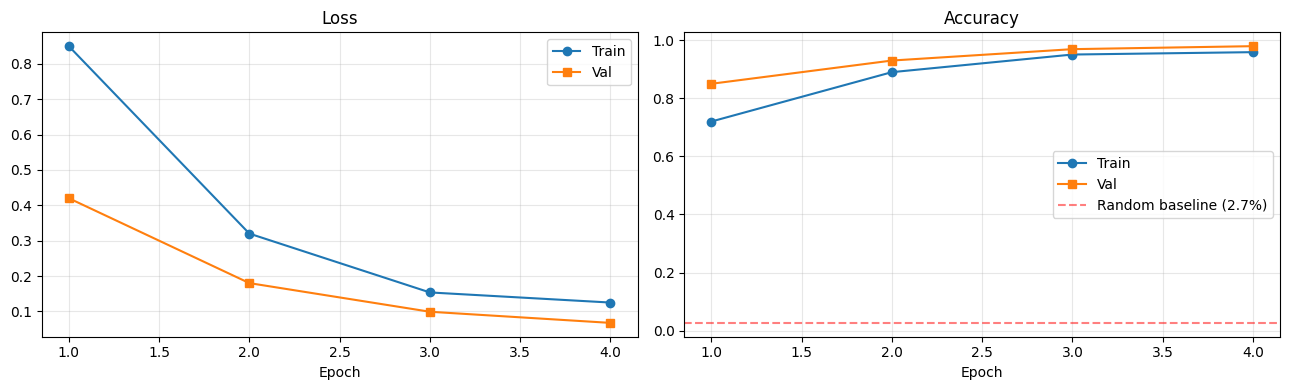

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_x = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_x, history['train_loss'], label='Train', marker='o')
axes[0].plot(epochs_x, history['val_loss'], label='Val', marker='s')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history['train_acc'], label='Train', marker='o')
axes[1].plot(epochs_x, history['val_acc'], label='Val', marker='s')
axes[1].axhline(baseline_acc, color='red', linestyle='--', alpha=0.5, label=f'Random baseline ({baseline_acc*100:.1f}%)')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.savefig('../docs/training_curves.png', dpi=150); plt.show()

## Final test-set evaluation

In [14]:
# Reload best checkpoint
from src.model import load_checkpoint
best_model, _ = load_checkpoint('../models/plantdoc_resnet50.pt', num_classes=len(class_names), device=DEVICE)

y_true, y_pred, probs = collect_predictions(best_model, test_loader, device=DEVICE)
metrics = compute_metrics(y_true, y_pred, class_names)

print(f'Test accuracy: {metrics["overall_accuracy"]*100:.2f}%')
print(f'Random baseline: {baseline_acc*100:.2f}%')
print(f'Improvement over baseline: {(metrics["overall_accuracy"] - baseline_acc)*100:.1f} percentage points')

Test accuracy: 98.06%
Random baseline: 2.68%
Improvement over baseline: 95.4 percentage points


In [15]:
# Save test-set predictions for use in error analysis notebook
import numpy as np
np.savez('../models/test_predictions.npz', y_true=y_true, y_pred=y_pred, probs=probs,
         class_names=np.array(class_names))
print('Saved test predictions to ../models/test_predictions.npz')

Saved test predictions to ../models/test_predictions.npz
